#Keras

##Installization Keras

In [1]:
pip install keras tensorflow

##Identifying the version of Keras

In [2]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


#1. Use Numpy

##Manual Gradient Calculation in Numpy

In [3]:
import numpy as np
# Simple function f(x) = x^2
def f(x):
  return x ** 2
# Manual derivative (f’(x) = 2x)
def gradient(x):
  return 2 * x
# Update rule: x = x- learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10): # Manually optimize for 10 steps
 x-= learning_rate * gradient(x)
print(f"x: {x}, f(x): {f(x)}")

x: 0.5368709120000001, f(x): 0.2882303761517119


##Gradient Computations with Keras

In [4]:
import tensorflow as tf
x = tf.Variable(5.0) # Trainable variable
with tf.GradientTape() as tape:
   y = x ** 2 # y = x^2
grad = tape.gradient(y, x) # Computes dy/dx automatically
print(grad.numpy()) # Output: 10.0

10.0


#2. Numpy is Slow for Large Models:

##Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU)

In [5]:
import numpy as np
import tensorflow as tf
import time
# Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)
# NumPy Multiplication
start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time()- start)
# TensorFlow Multiplication (for colab uses GPU Runtime if available)
A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time()- start)

NumPy Time: 0.1733553409576416
TensorFlow Time: 0.15994048118591309


In [49]:
import tensorflow as tf
from tensorflow import keras

# Assuming x_train and y_train are already loaded and preprocessed
# (e.g., from Devangari dataset or MNIST and reshaped to 28*28 for flattened input)
# If x_train is (17000, 28, 28, 1), it needs to be flattened for this model.
# Let's define the model and compile it again to ensure it's in a correct state.

num_classes = 10
input_shape = (28, 28, 1) # This is the shape before flattening

# Re-define the model from previous example (Sequential API: cell vyBz1wMUWYpi)
model = keras.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(),  # Flatten 28x28x1 to 784
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
])

# Re-compile the model from previous example (cell ka5ise1tXLnQ)
model.compile(
    optimizer="sgd",  # Stochastic Gradient Descent
    loss="categorical_crossentropy",  # Multi-class classification
    metrics=["accuracy"]  # Track accuracy
)

# Now call fit() and assign the history object
history = model.fit(x_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1109 - loss: 2.3041
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1276 - loss: 2.2949
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1616 - loss: 2.2782
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.2527 - loss: 2.2331
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3561 - loss: 2.0481
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4572 - loss: 1.6228
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5473 - loss: 1.3154
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6278 - loss: 1.1134
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7048 - loss: 0.9253
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7598 - loss: 0.7848


#3. No Pre-built Activation Functions and Layers in NumPy.

In [24]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation='sigmoid')

#4. Keras supports Model Training, Numpy Does not:

## Manually Training Network in Numpy.

##keras training is One Line.

In [25]:
import numpy as np

# Sample data and weights (for demonstration)
x_train = np.random.rand(100, 10) # 100 samples, 10 features
y_train = np.random.rand(100, 1)  # 100 samples, 1 output
weights = np.random.rand(10, 1)   # 10 features, 1 output
learning_rate = 0.01

for epoch in range(10):
  # Forwardpass
  y_pred=np.dot(x_train,weights)
  # Computeloss
  loss=np.mean((y_pred-y_train)**2)
  # Computegradientsmanually
  gradients=2*np.dot(x_train.T,(y_pred-y_train))/len(x_train)
  # Updateweights
  weights-=learning_rate*gradients

print(f"Final Loss: {loss:.4f}")

Final Loss: 3.1645


#5. No Prebuilt Layers in Numpy:

## Layers in Keras.

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model =Sequential([
Dense(64,activation='relu',input_shape=(784,)),
Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#6. No prebuilt Optimizers in NumPy:

##Implementing SGD in Numpy.

In [30]:
learning_rate = 0.01
weights = np.random.randn(3,3)
for _ in range(100): #Training loop
    gradient=np.random.randn(3,3) #Fake gradient for illustration
    weights -= learning_rate*gradient

##In Keras

In [32]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate=0.01)

# 3 Understanding Fully Connected Layers.



##Suntax of Dense Layer.

In [34]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation=None, use_bias=True, kernel_initializer="glorot_uniform")

## A Dense Layer with 64 Neurons and sigmoid Activation.

In [35]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation="sigmoid") # 64 neurons with sigmoid activation

#4. Building a SimpleFully Connected Neural Network in Keras.

In [36]:
import zipfile

zip_path = '/content/drive/MyDrive/AI and Machine Learning/Week4/Copy of Copy of devnagari digit.zip'
extract_path = '/content/drive/MyDrive/AI and Machine Learning/Week4/unzipped_data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

##Loading and Preprocessing Data with PIL.

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


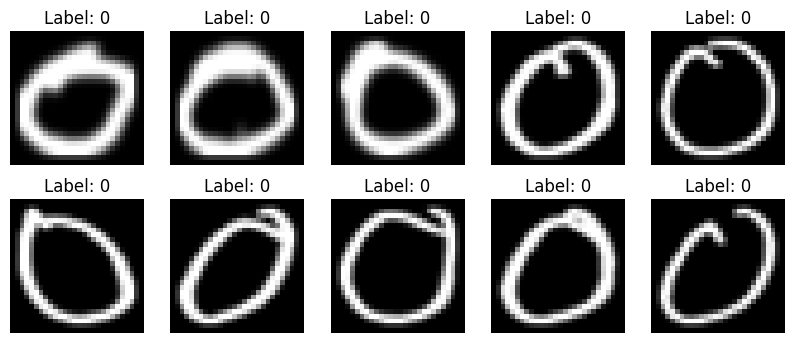

In [17]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image  # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/AI and Machine Learning/Week4/unzipped_data/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI and Machine Learning/Week4/unzipped_data/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))  # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # Load image using PIL
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))  # Resize to (28, 28)
            img = np.array(img) / 255.0  # Normalize to [0,1]

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.show()

#Reshaping for Keras compatibility:

##Compatibility check for Grayscale Image:

In [42]:
x_train = x_train.reshape(-1, img_height, img_width, 1)
# Use with Cautions.

##Compatibility check for RGB Image:

In [41]:
# x_train = x_train.reshape(-1, img_height, img_width, 3)
# Use with Cautions.

##Loading and Preprocessing MNIST Hand written Digit Dataset:

In [40]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the images to values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

# One-hot encode the labels (0-9) for classification
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Build the Model:

##1. Sequential API:

In [39]:
# Model parameters
import tensorflow as tf
from tensorflow import keras

num_classes = 10
input_shape = (28, 28, 1)

model = keras.Sequential([
    keras.layers.Input(shape=input_shape),

    keras.layers.Flatten(),  # Flatten 28x28 → 784

    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),

    keras.layers.Dense(num_classes, activation="softmax"),
])

##2. Functional API:

In [38]:
# Model parameters
import tensorflow as tf
from tensorflow import keras

num_classes = 10
input_shape = (28, 28, 1)

def build_functional_model():
    # Input layer
    inputs = keras.Input(shape=input_shape)

    # Flatten layer
    x = keras.layers.Flatten()(inputs)

    # Hidden layers
    x = keras.layers.Dense(64, activation="sigmoid")(x)
    x = keras.layers.Dense(128, activation="sigmoid")(x)
    x = keras.layers.Dense(256, activation="sigmoid")(x)

    # Output layer
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs)

    return model

# Build the model
functional_model = build_functional_model()

# Show summary
functional_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##3. Compiling and Training the Model:

###Syntax of model.compile():

In [43]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

###Compiling the Model

In [44]:
model.compile(
    optimizer="sgd",  # Stochastic Gradient Descent
    loss="categorical_crossentropy",  # Multi-class classification
    metrics=["accuracy"]  # Track accuracy
)

##2.Training of the Model:

###Syntax of fit () function.

In [52]:
import tensorflow as tf
from tensorflow import keras # Added import for keras

# Define parameters (from cells 3JFls2F-76Em and kYMFhdIi786j to make this cell self-contained)
batch_size = 128
epochs = 20
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4),
]

# The model needs to be defined and compiled before fitting.
# Assuming `model`, `x_train`, `y_train` are available from previous cells
# (e.g., from cell `fhmo8ekZ9t46` or `vyBz1wMUWYpi` followed by `ka5ise1tXLnQ`)

# If model is not yet defined and compiled in the current session,
# you would need to run the model definition and compilation cells first.
# For demonstration, we'll assume `model` is available.

model.fit(
    x=x_train,
    y=y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.15, # Using validation_split as defined in an example
    callbacks=callbacks, # Using callbacks as defined in an example
    verbose=1 # Common verbose level
)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8814 - loss: 0.4257 - val_accuracy: 0.8900 - val_loss: 0.3852
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8820 - loss: 0.4221 - val_accuracy: 0.8907 - val_loss: 0.3819
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8833 - loss: 0.4187 - val_accuracy: 0.8928 - val_loss: 0.3786
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8839 - loss: 0.4154 - val_accuracy: 0.8916 - val_loss: 0.3757
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8848 - loss: 0.4121 - val_accuracy: 0.8928 - val_loss: 0.3725
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8860 - loss: 0.4088 - val_accuracy: 0.8951 - val_loss: 0.3698
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8869 - loss: 0.4056 - val_accuracy: 0.8953 - val_loss: 0.3672
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8876 - loss: 0.4025 - val_accuracy: 0.

###Example Code for fit()

In [54]:
batch_size = 128
epochs = 20
# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]
# Train the model with callbacks and validation split
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.15,
    callbacks=callbacks,
)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8988 - loss: 0.3612 - val_accuracy: 0.9070 - val_loss: 0.3283
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8996 - loss: 0.3587 - val_accuracy: 0.9089 - val_loss: 0.3261
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9005 - loss: 0.3560 - val_accuracy: 0.9089 - val_loss: 0.3246
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9014 - loss: 0.3535 - val_accuracy: 0.9093 - val_loss: 0.3216
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9022 - loss: 0.3510 - val_accuracy: 0.9117 - val_loss: 0.3194
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9029 - loss: 0.3485 - val_accuracy: 0.9112 - val_loss: 0.3173
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9033 - loss: 0.3460 - val_accuracy: 0.9131 - val_loss: 0.3153
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9042 - loss: 0.3435 - val_accuracy: 0

###1.Parameters and Setup:

In [55]:
batch_size = 128
epochs = 20

###2.Callbacks

In [56]:
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4),
]

###3.Training the Model

In [57]:
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.15,
    callbacks=callbacks,
)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9130 - loss: 0.3129 - val_accuracy: 0.9208 - val_loss: 0.2860
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9136 - loss: 0.3106 - val_accuracy: 0.9220 - val_loss: 0.2841
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9140 - loss: 0.3083 - val_accuracy: 0.9220 - val_loss: 0.2823
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9146 - loss: 0.3063 - val_accuracy: 0.9218 - val_loss: 0.2803
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9155 - loss: 0.3039 - val_accuracy: 0.9216 - val_loss: 0.2796
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9158 - loss: 0.3019 - val_accuracy: 0.9233 - val_loss: 0.2765
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9168 - loss: 0.2997 - val_accuracy: 0.9218 - val_loss: 0.2753
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9170 - loss: 0.2976 - val_accuracy: 0.

##Sample Code for visualizing Model’s Training Progress

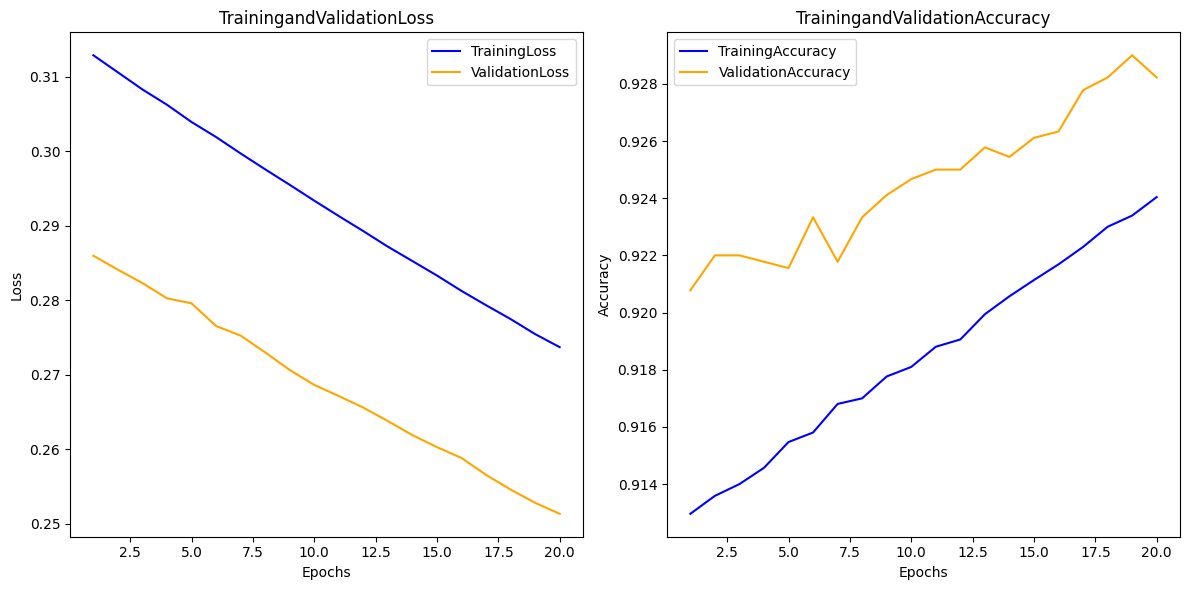

In [58]:
import matplotlib.pyplot as plt
#Assuming'history'istheobjectreturnedbymodel.fit()
#Extractingtrainingandvalidationloss
train_loss=history.history['loss']
val_loss=history.history['val_loss']
#Extractingtrainingandvalidationaccuracy(ifmetricswerespecified)
train_acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
#Plottingtrainingandvalidationloss
plt.figure(figsize=(12,6))
plt.subplot(1,2, 1)
plt.plot(range(1, len(train_loss)+1), train_loss,label='TrainingLoss',color='blue')
plt.plot(range(1, len(val_loss)+1),val_loss,label='ValidationLoss',color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('TrainingandValidationLoss')
plt.legend()
#Plottingtrainingandvalidationaccuracy
plt.subplot(1,2, 2)
plt.plot(range(1, len(train_acc)+1),train_acc,label='TrainingAccuracy',color='blue')
plt.plot(range(1, len(val_acc)+1),val_acc,label='ValidationAccuracy',color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('TrainingandValidationAccuracy')
plt.legend()
plt.tight_layout()
plt.show()

##4.Evaluate the Model:

###Syntax for model.evaluate()

###Example code for Evaluation.

In [66]:
# Reshape x_test to match the model's expected input shape (batch, height, width, channels)
x_test_reshaped = x_test.reshape(-1, 28, 28, 1)

test_loss, test_acc = model.evaluate(x_test_reshaped, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.9265 - loss: 0.2698
Test accuracy: 0.9265


###5.Making Predictions with Keras:

####Example code for model.predict()

In [71]:
# Reshape x_test to match the model's expected input shape (batch, height, width, channels)
x_test_reshaped_for_prediction = x_test.reshape(-1, 28, 28, 1)

# Predict on test data
predictions = model.predict(x_test_reshaped_for_prediction)

# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted label for first image: 7
True label for first image: 7


###6. Saving and Loading the Model:

####1. Saving the Model:

In [73]:
model.save('mnist_fully_connected_model.h5')

####2. Loading the Model:

In [75]:
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')

#Exercise

##Task 1

###Import required libraries

In [76]:
import os
import numpy as np
from PIL import Image

###function to load images

In [84]:
def load_data(folder_path):
    images = []
    labels = []

    for label_name in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label_name)

        if os.path.isdir(label_path):
            # Extract the numeric part of the label name (e.g., '0' from 'digit_0')
            label = int(label_name.split('_')[1])

            for file in os.listdir(label_path):
                img_path = os.path.join(label_path, file)

                # Load image
                img = Image.open(img_path).convert('L')  # grayscale

                # Resize to 28x28
                img = img.resize((28, 28))

                # Convert to numpy + normalize
                img_array = np.array(img) / 255.0

                images.append(img_array)
                labels.append(label)

    return np.array(images), np.array(labels)

###Load training data

In [86]:
x_train, y_train = load_data("/content/drive/MyDrive/AI and Machine Learning/Week4/unzipped_data/DevanagariHandwrittenDigitDataset/Train")
x_test, y_test = load_data("/content/drive/MyDrive/AI and Machine Learning/Week4/unzipped_data/DevanagariHandwrittenDigitDataset/Test")

###Check data

In [87]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(17000, 28, 28)
(17000,)
(3000, 28, 28)
(3000,)


###Convert labels to One-Hot

In [88]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

##Task 2

###Build the FCN Model

####Import Keras layers and Sequential

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

####Reshape your data

In [90]:
# Flatten 28x28 images into 784-length vectors
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

print(x_train_flat.shape, x_test_flat.shape)
# Example output: (num_train_samples, 784) (num_test_samples, 784)

(17000, 784) (3000, 784)


####Build the model

In [91]:
model = Sequential()

# 1st hidden layer: 64 neurons, sigmoid
model.add(Dense(64, activation='sigmoid', input_shape=(784,)))

# 2nd hidden layer: 128 neurons, sigmoid
model.add(Dense(128, activation='sigmoid'))

# 3rd hidden layer: 256 neurons, sigmoid
model.add(Dense(256, activation='sigmoid'))

# Output layer: 10 neurons, softmax
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


####Check the model summary

In [92]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##Task 3

###Compile the Model

In [94]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(),                 # Adam optimizer
    loss='categorical_crossentropy',  # use categorical_crossentropy for one-hot labels
    metrics=['accuracy']              # track accuracy
)

###Verify compilation

In [95]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##Task 4

###Import callbacks

In [96]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

###callbacks

In [97]:
# Save the best model based on validation accuracy
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Stop training early if validation loss does not improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1
)

###Train the model

In [98]:
history = model.fit(
    x_train_flat,           # flattened training images
    y_train,                # one-hot labels
    batch_size=128,
    epochs=20,
    validation_split=0.2,   # 20% of training data for validation
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2655 - loss: 2.0247
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4619 - loss: 1.6598 - val_accuracy: 0.0000e+00 - val_loss: 6.7707
Epoch 2/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8070 - loss: 0.6692
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8307 - loss: 0.5350 - val_accuracy: 0.0000e+00 - val_loss: 7.9659
Epoch 3/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8957 - loss: 0.3198
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9129 - loss: 0.2879 - val_accuracy: 0.0000e+00 - val_loss: 8.6474
Epoch 4/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9443 - loss: 0.2013
Epoch 4: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9460 - loss: 0.1895 - val_accuracy: 0.0000e+00 - val_loss: 8.9910
Epoch 5/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - a

##Task 5

###Model Evalution

In [100]:
from tensorflow.keras.models import load_model

# Load the best model saved during training
best_model = load_model('best_model.h5')
loss, accuracy = best_model.evaluate(x_test_flat, y_test, verbose=1)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6203 - loss: 2.0443
Test Loss: 2.0442898273468018
Test Accuracy: 0.6203333139419556


##Task 6

###Save and Load the Model

In [101]:
#Save the trained model
best_model.save("devnagari_fcn.h5")
print("Model saved as devnagari_fcn.h5")

#Load the saved model
loaded_model = load_model("devnagari_fcn.h5")
print("Model loaded successfully")

#Re-evaluate loaded model on test set
loss, accuracy = loaded_model.evaluate(x_test_flat, y_test, verbose=1)
print("Loaded Model Test Loss:", loss)
print("Loaded Model Test Accuracy:", accuracy)

Model saved as devnagari_fcn.h5
Model loaded successfully
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6203 - loss: 2.0443
Loaded Model Test Loss: 2.0442898273468018
Loaded Model Test Accuracy: 0.6203333139419556


##Task 7

###Make Predictions

In [102]:
# predict probabilities on test set
predictions = loaded_model.predict(x_test_flat)

#Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

#Convert one-hot true labels to class labels
true_labels = np.argmax(y_test, axis=1)

#Show first 10 predictions
print("Predicted labels:", predicted_labels[:10])
print("True labels     :", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted labels: [0 0 0 0 0 0 0 0 0 0]
True labels     : [0 0 0 0 0 0 0 0 0 0]


##Final Deliverables: Devnagari Digit FCN

### Visualization: Training & Validation

Final Test Accuracy: 0.6203
Model saved as devnagari_fcn.h5


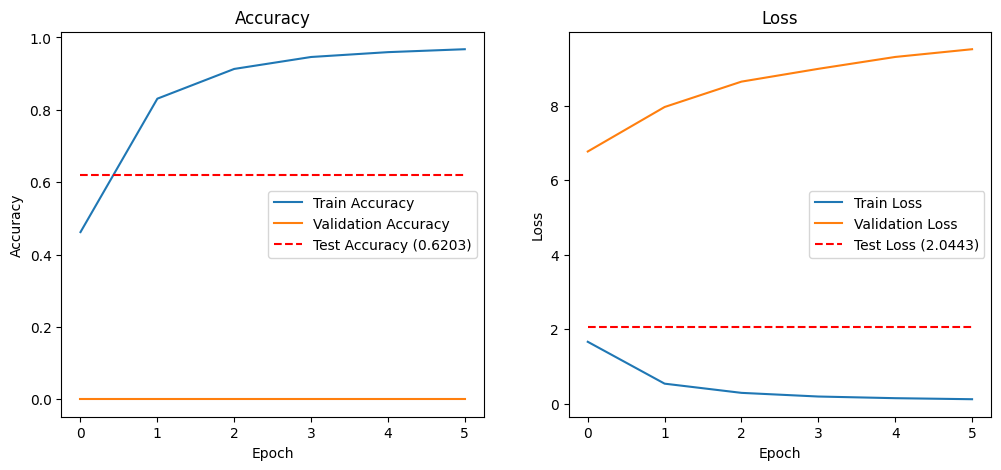

In [105]:
# Evaluate test set
test_loss, test_accuracy = loaded_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Final Test Accuracy: {test_accuracy:.4f}")

# Save the model
loaded_model.save('devnagari_fcn.h5')
print("Model saved as devnagari_fcn.h5")

# Plot train, validation, and test
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.hlines(test_accuracy, 0, len(history.history['accuracy'])-1, colors='r', linestyles='dashed', label=f'Test Accuracy ({test_accuracy:.4f})')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.hlines(test_loss, 0, len(history.history['loss'])-1, colors='r', linestyles='dashed', label=f'Test Loss ({test_loss:.4f})')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()